<a href="https://colab.research.google.com/github/yashkapur0403/Yash_Kapur_ML_Lab_Work/blob/main/random_foresttt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

(145, 32)
GRADE
1    35
2    24
3    21
5    17
7    17
6    13
4    10
0     8
Name: count, dtype: int64


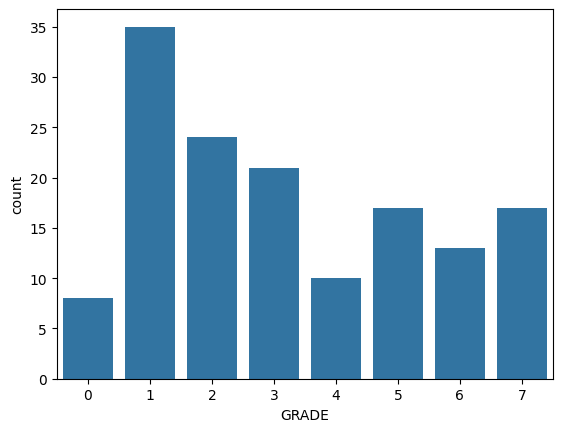

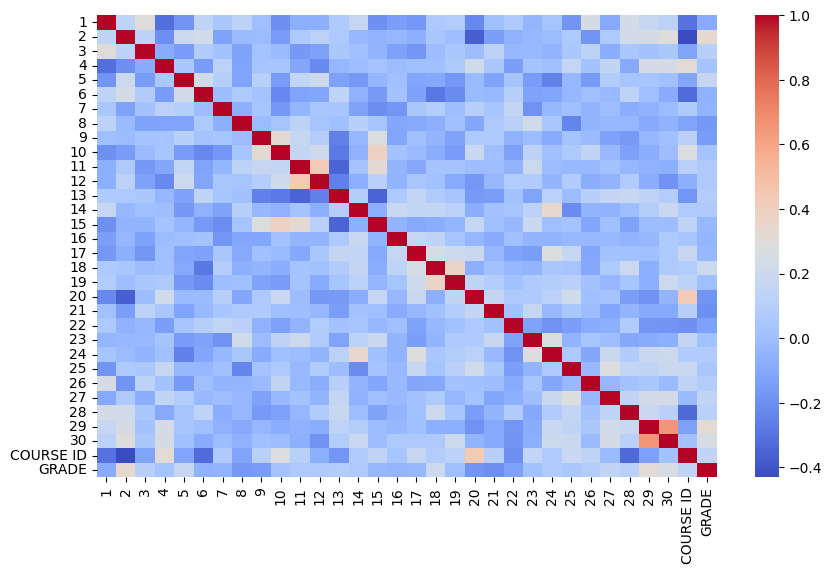

In [2]:
df = pd.read_csv('DATA (1).csv')
df = df.drop(columns=['STUDENT ID'])

df = df.apply(pd.to_numeric, errors='ignore')
df.fillna(df.median(numeric_only=True), inplace=True)

print(df.shape)
print(df['GRADE'].value_counts())

sns.countplot(x='GRADE', data=df)
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [3]:
X = df.drop('GRADE', axis=1)
y = df['GRADE']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.1724137931034483
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         4
           1       0.12      0.67      0.21         3
           2       0.40      0.50      0.44         4
           3       0.00      0.00      0.00         6
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.00      0.00      0.00         4
           7       0.33      0.50      0.40         2

    accuracy                           0.17        29
   macro avg       0.11      0.21      0.13        29
weighted avg       0.09      0.17      0.11        29



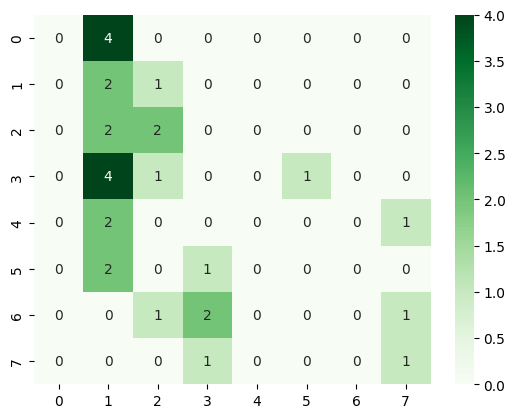

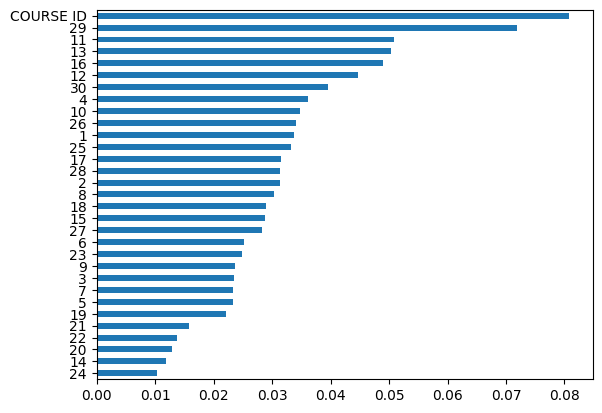

0.27586206896551724
0.1724137931034483
0.2068965517241379
0.3103448275862069


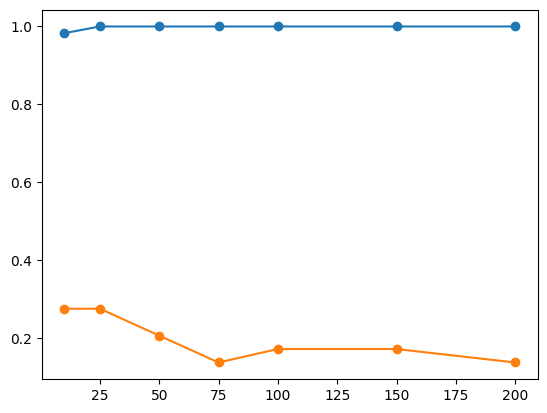

In [4]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.show()

importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
importance.plot(kind='barh')
plt.show()

dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train, y_train)

acc_dt = accuracy_score(y_test, dt.predict(X_test))
acc_rf = accuracy_score(y_test, y_pred)

print(acc_dt)
print(acc_rf)

cv_dt = cross_val_score(dt, X, y, cv=5)
cv_rf = cross_val_score(rf, X, y, cv=5)

print(cv_dt.mean())
print(cv_rf.mean())

n_trees = [10, 25, 50, 75, 100, 150, 200]
train_acc = []
test_acc = []

for n in n_trees:
    model = RandomForestClassifier(n_estimators=n, max_depth=10, random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))

plt.plot(n_trees, train_acc, marker='o')
plt.plot(n_trees, test_acc, marker='o')
plt.show()